In [1]:
!pip install librosa

In [9]:
# ------------------------------
# IMPORTS
# ------------------------------

import numpy as np
import os
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# ------------------------------
# REPRODUCIBILIDAD
# ------------------------------

np.random.seed(42)
tf.random.set_seed(42)


# dataset/
#    rock/
#    pop/
#    jazz/
#    classical/
#    hiphop/
#    electronic/
!wget https://web.archive.org/web/20220328223413/ftp://opihi.cs.uvic.ca/sound/genres.tar.gz
!tar -xzf genres.tar.gz

DATASET_PATH = "genres"
SAMPLE_RATE = 22050
DURATION = 30

CHUNK_DURATION = 3  # clave
SAMPLES_PER_CHUNK = SAMPLE_RATE * CHUNK_DURATION

N_MELS = 128
HOP_LENGTH = 512


--2026-04-08 00:12:50--  https://web.archive.org/web/20220328223413/ftp://opihi.cs.uvic.ca/sound/genres.tar.gz
Resolving web.archive.org (web.archive.org)... 207.241.237.3
Connecting to web.archive.org (web.archive.org)|207.241.237.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1225571541 (1.1G) [application/x-gzip]
Saving to: ‘genres.tar.gz’

genres.tar.gz       100%[===================>]   1.14G  22.9MB/s    in 66s     

2026-04-08 00:14:10 (17.8 MB/s) - ‘genres.tar.gz’ saved [1225571541/1225571541]



In [10]:

# ------------------------------
# GPU
# ------------------------------

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU activa")
else:
    print("CPU activa")

GPU activa


In [11]:
# ------------------------------
# FUNCIÓN: MEL SPECTROGRAM
# ------------------------------

def extract_mel(signal, sr):
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=N_MELS,
        hop_length=HOP_LENGTH
    )

    mel_db = librosa.power_to_db(mel)

    return mel_db.astype(np.float32)

In [12]:
# ------------------------------
# FUNCIÓN: DIVIDIR AUDIO EN CHUNKS
# ------------------------------
def split_chunks(signal):
    chunks = []

    for i in range(0, len(signal), SAMPLES_PER_CHUNK):
        chunk = signal[i:i + SAMPLES_PER_CHUNK]

        if len(chunk) == SAMPLES_PER_CHUNK:
            chunks.append(chunk)

    return chunks

In [13]:
# ------------------------------
# FUNCIÓN: CARGA DEL DATASET
# ------------------------------
def load_dataset(dataset_path):
    X, y = [], []

    for genre in sorted(os.listdir(dataset_path)):
        genre_path = os.path.join(dataset_path, genre)

        if not os.path.isdir(genre_path):
            continue

        print("Procesando:", genre)

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            try:
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                chunks = split_chunks(signal)

                for chunk in chunks:
                    mel = extract_mel(chunk, sr)

                    # normalizar por muestra
                    mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

                    X.append(mel)
                    y.append(genre)

            except Exception as e:
                print("Error:", file_path, e)

    return np.array(X), np.array(y)

In [14]:
# ------------------------------
# CARGAR DATOS
# ------------------------------
X, y = load_dataset(DATASET_PATH)

# reshape para CNN
X = X[..., np.newaxis]  # (samples, mel, time, 1)

# ------------------------------
# ENCODING DE ETIQUETAS
# ------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# ------------------------------
# TRAIN / TEST SPLIT
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_encoded, random_state=42
)

Procesando: blues
Procesando: classical
Procesando: country
Procesando: disco
Procesando: hiphop
Procesando: jazz
Procesando: metal
Procesando: pop
Procesando: reggae
Procesando: rock


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input

# ------------------------------
# MODELO CNN2D
# ------------------------------

model = Sequential([
    Input(shape=X.shape[1:]),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(y_train.shape[1], activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,250 (12.61 MB)

 Trainable params: 3,305,802 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
# ------------------------------
# CALLBACKS
# ------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5)
]

# ------------------------------
# ENTRENAMIENTO
# ------------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.3322 - loss: 2.0125 - val_accuracy: 0.2286 - val_loss: 3.0293 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4723 - loss: 1.6855 - val_accuracy: 0.4987 - val_loss: 1.6867 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5561 - loss: 1.5135 - val_accuracy: 0.6398 - val_loss: 1.4055 - learning_rate: 1.0000e-04
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6318 - loss: 1.3694 - val_accuracy: 0.6963 - val_loss: 1.2942 - learning_rate: 1.0000e-04
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7060 - loss: 1.2318 - val_accuracy: 0.7204 - val_loss: 1.2321 - learning_rate: 1.0000e-04
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7570 - loss: 1.1350 - val_accuracy: 0.7009 - val_loss: 1.2520 - learning_rate: 1.0000e-04
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - a

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


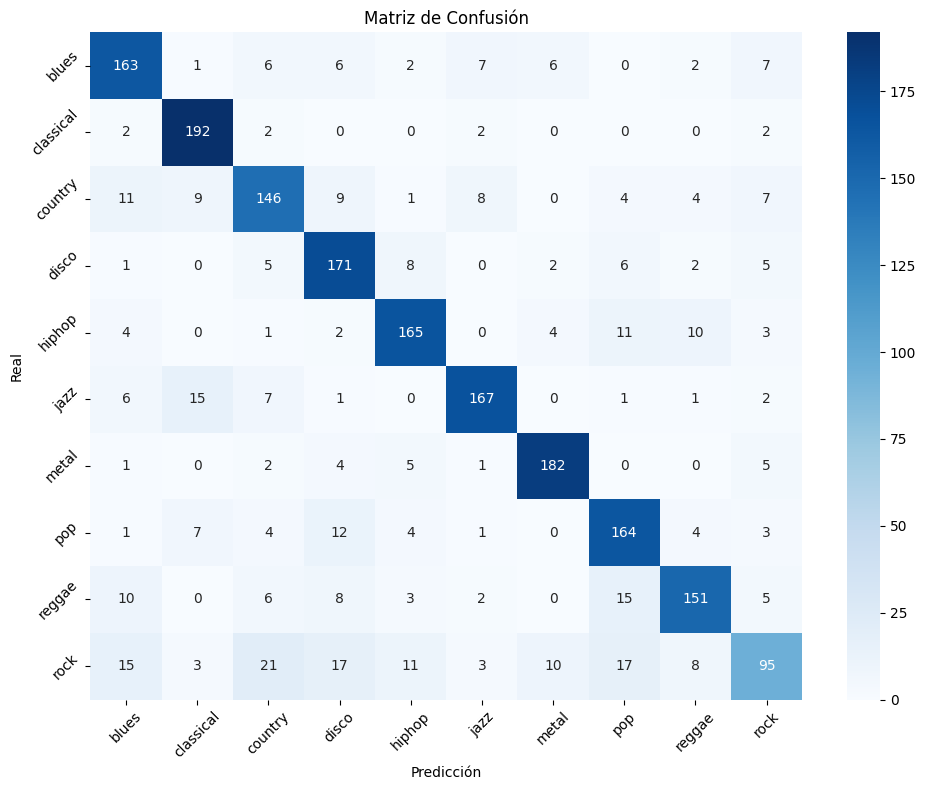

              precision    recall  f1-score   support

       blues       0.76      0.81      0.79       200
   classical       0.85      0.96      0.90       200
     country       0.73      0.73      0.73       199
       disco       0.74      0.85      0.80       200
      hiphop       0.83      0.82      0.83       200
        jazz       0.87      0.83      0.85       200
       metal       0.89      0.91      0.90       200
         pop       0.75      0.82      0.78       200
      reggae       0.83      0.76      0.79       200
        rock       0.71      0.47      0.57       200

    accuracy                           0.80      1999
   macro avg       0.80      0.80      0.79      1999
weighted avg       0.80      0.80      0.79      1999



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ------------------------------
# MATRIZ DE CONFUCION
# ------------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=le.classes_))

In [18]:
# ------------------------------
# EVALUACIÓN
# ------------------------------
loss, acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy test: {acc*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7984 - loss: 1.0475

Accuracy test: 79.84%


In [19]:
# ------------------------------
# PREDICCIÓN CON VOTING
# ------------------------------
def predict_genre(file_path, model, label_encoder):
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    chunks = split_chunks(signal)

    preds = []

    for chunk in chunks:
        mel = extract_mel(chunk, sr)
        mel = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)

        mel = mel[np.newaxis, ..., np.newaxis]

        pred = model.predict(mel, verbose=0)
        preds.append(pred[0])

    preds = np.array(preds)

    # promedio de predicciones
    final_pred = np.mean(preds, axis=0)

    idx = np.argmax(final_pred)

    # Graficar
    plt.figure(figsize=(10, 5))
    plt.bar(label_encoder.classes_, final_pred, color='skyblue')
    plt.title("Distribución de Probabilidades por Género")
    plt.ylabel("Probabilidad")
    plt.xticks(rotation=45)
    plt.show()

    print("\nResultado final:")
    for i, p in enumerate(final_pred):
        print(f"{label_encoder.classes_[i]}: {p*100:.2f}%")

    return label_encoder.classes_[idx]

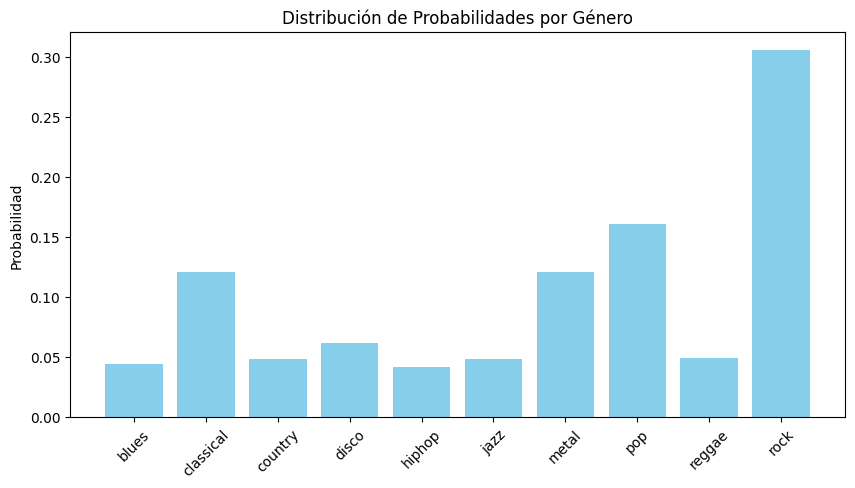


Resultado final:
blues: 4.40%
classical: 12.07%
country: 4.82%
disco: 6.17%
hiphop: 4.19%
jazz: 4.80%
metal: 12.04%
pop: 16.10%
reggae: 4.89%
rock: 30.52%


np.str_('rock')

In [22]:
# ------------------------------
# EJEMPLO DE USO
# ------------------------------
predict_genre("test-rock.wav", model, le)

In [21]:

# ------------------------------
# GUARDAR MODELO
# ------------------------------
model.save("music_genre_classifier.keras")
print("Modelo guardado correctamente")

Modelo guardado correctamente
